## README:

* Cells labeled with '## ----- CONFIG ----- ##' contain parameters that need to be set manually

In [ ]:
%%capture
!pip install FinRL
!pip install stable_baselines3
!pip install alpaca_trade_api
!pip install exchange_calendars
!pip install stockstats
!pip install wrds
!pip install websockets
!pip install yfinance
!pip install ta
!pip install sb3_contrib

In [29]:
import os
import sys
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from finrl.meta.preprocessor.preprocessors import data_split
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold

# Import the custom_env module directly to make it reloadable
import trading_environment.custom_env
from evaluation.backtest import run_backtest
from evaluation.visualize import plot_trades_on_price_from_backtest

import importlib
# Reload the custom_env module
importlib.reload(trading_environment.custom_env)

# Get the StockTradingEnv class from the reloaded module
StockTradingEnv = trading_environment.custom_env.StockTradingEnv

In [5]:
import os
import sys
# add project root to path
# Assuming module folders are directly in the current working directory (e.g., /content)
root_path = os.getcwd()
sys.path.append(root_path)

## Load env variables

In [6]:
load_dotenv(r'../.env')

DATA_DIR = os.getenv('DATA_DIR')

## Train-test split and normalization

In [7]:
## ----- CONFIG ----- ##
SPLIT_DATE = '2018-01-01' # format %Y-%m-%d
DATA_FILE_NAME = 'data_with_features.csv'

In [8]:
# load finalized data
if DATA_DIR is None:
    DATA_DIR = '/content'
data_df = pd.read_csv(os.path.join(DATA_DIR, DATA_FILE_NAME))
data_df['date'] = pd.to_datetime(data_df['date'], format='%Y-%m-%d')
data_df.shape

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


(60543, 26)

In [9]:
SPLIT_DATE = pd.to_datetime(SPLIT_DATE, format='%Y-%m-%d')

# train-test split
min_date = data_df['date'].min()
max_date = data_df['date'].max()

train_df = data_split(data_df, start=min_date, end=SPLIT_DATE)
trade_df = data_split(data_df, start=SPLIT_DATE + pd.Timedelta(days=1), end=max_date)

print(train_df.shape, trade_df.shape)

(42606, 26) (17928, 26)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [37]:
from sklearn.preprocessing import StandardScaler

## ----- CONFIG ----- ##
stock_features = [
    'macd',
    'macd_hist',
    'cci_30',
]

economy_features = [
    'CPIAUCSL',
    'DFF',
    'ICSA',
    'T10Y2Y',
    'VIXCLS',
    'friday',
    'month_sin',
    'month_cos'
]

stock_names = data_df['tic'].unique()

features_to_normalize = stock_features + economy_features

# Initialize StandardScaler
scaler = StandardScaler()

for tic in stock_names:
  for feature in features_to_normalize:
    # Fit scaler only on training data features to avoid data leakage
    train_df.loc[train_df['tic'] == tic, feature] = scaler.fit_transform(train_df.loc[train_df['tic'] == tic, feature].values.reshape(-1, 1))
    # Transform both training and trading data features using the fitted scaler
    trade_df.loc[trade_df['tic'] == tic, feature] = scaler.transform(trade_df.loc[trade_df['tic'] == tic, feature].values.reshape(-1, 1))

# check for NAs
print('Any missing values in training:', train_df.isna().any().any())
print('Any missing values in testing:', trade_df.isna().any().any())

Any missing values in training: False
Any missing values in testing: False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Environment configuration

In [11]:
## ----- CONFIG ----- ##
price = 'close'         # name of price to use for transactions / rewards
hmax = 100              # maximum number of stocks to transact at each step
initial_amount = 5000   # initial amount of cash
buy_cost_pct = 0.005    # % cost of each stock purchase
sell_cost_pct = 0.005   # % cost of each stock sale
num_stock_shares = 0    # number of starting shares
window_size = 100       # number of previous time steps to encode
reward_scaling = 1      # reward scaling

In [38]:
# environment kwargs
stock_dim = len(data_df['tic'].unique())
state_space = 1 + 2 * stock_dim + len(stock_features) * stock_dim + len(economy_features)

env_kwargs = {
    "price": price,
    "hmax": hmax,
    "initial_amount": initial_amount,
    "buy_cost_pct": [buy_cost_pct] * stock_dim,
    "sell_cost_pct": [sell_cost_pct] * stock_dim,
    "stock_dim": stock_dim,
    "state_space": state_space,
    "action_space": stock_dim,
    "reward_scaling": 1,
    "num_stock_shares": [num_stock_shares] * stock_dim,
    "price": "close",
    "stock_features": stock_features,
    "economy_features": economy_features,
    "window_size": window_size
}


## Model training

In [39]:
# build training env
env_train_vec = DummyVecEnv([lambda: Monitor(StockTradingEnv(df=train_df, **env_kwargs))])

# build trading/backtest env
env_trade_vec = DummyVecEnv([lambda: Monitor(StockTradingEnv(df=trade_df, **env_kwargs))])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [40]:
policy_kwargs = dict(
    net_arch=[64, 64],
    lstm_hidden_size=16,
    n_lstm_layers=1,
    shared_lstm=False,
    enable_critic_lstm=True
)

model = RecurrentPPO(
    policy="MlpLstmPolicy",
    env=env_train_vec,

    # --- PPO rollout & update ---
    n_steps=64,
    batch_size=32,
    n_epochs=5,
    gamma=0.99,              # long-ish horizon for cyclic pattern
    gae_lambda=0.95,

    # --- Optimization ---
    learning_rate=3e-4,      # a bit smaller since env is noise-free
    max_grad_norm=0.5,
    clip_range=0.15,         # slightly tighter clipping for stability
    vf_coef=0.5,
    ent_coef=0.10,           # non-zero exploration

    # --- Misc ---
    verbose=0,
    tensorboard_log=None,
    policy_kwargs=policy_kwargs,
)

In [41]:
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=5000)
eval_callback = EvalCallback(
    env_train_vec,
    callback_on_new_best=stop_callback,
    eval_freq=1_000,
    verbose=1,
)

model.learn(total_timesteps=50_000, callback=eval_callback)

Eval num_timesteps=1000, episode_reward=24845.45 +/- 0.00
Episode length: 4634.00 +/- 0.00
New best mean reward!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Quick evaluation

In [42]:
trade_env = StockTradingEnv(df=trade_df, **env_kwargs)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [43]:
import evaluation.backtest
import importlib

# Reload the entire backtest module
importlib.reload(evaluation.backtest)

# Now call the run_backtest function from the reloaded module
res = evaluation.backtest.run_backtest(
    model,
    trade_env,
    env_kwargs
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


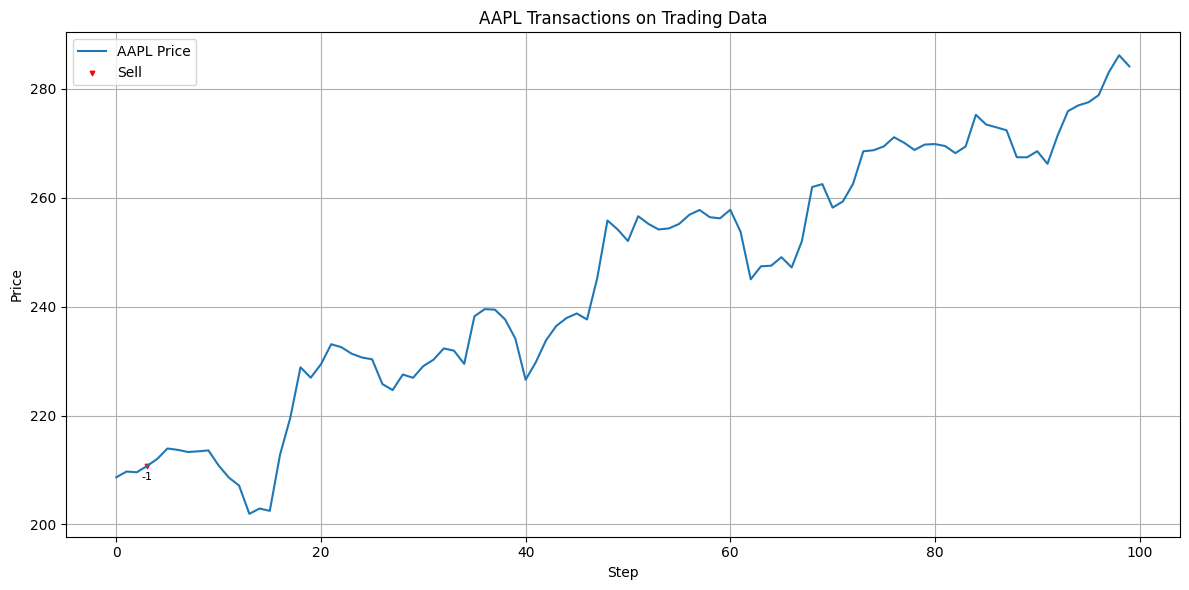

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


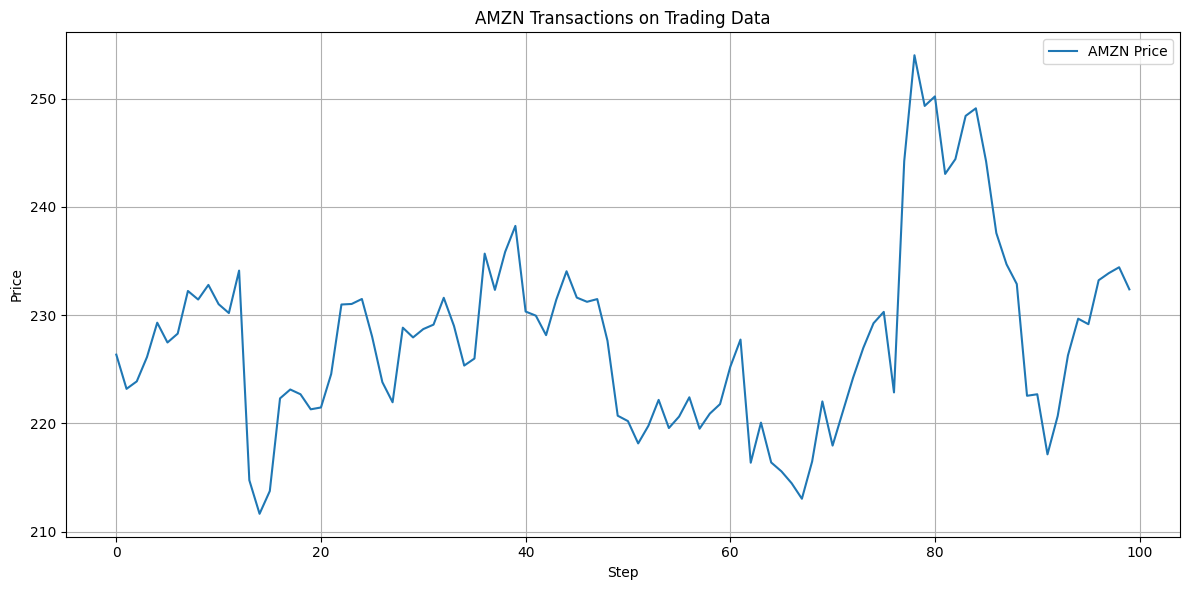

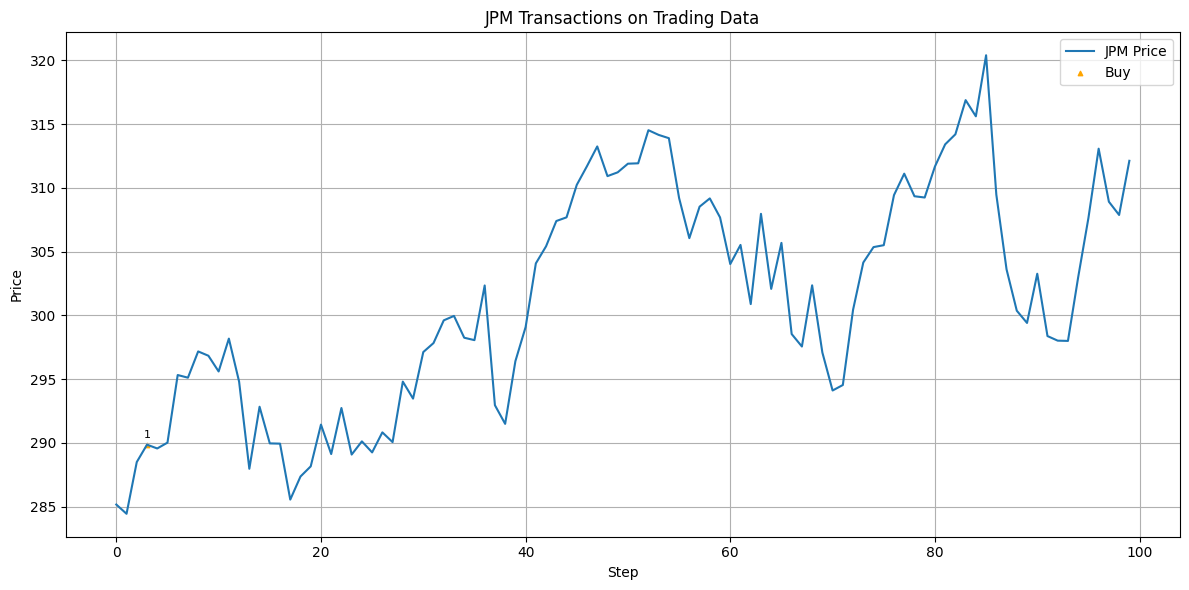

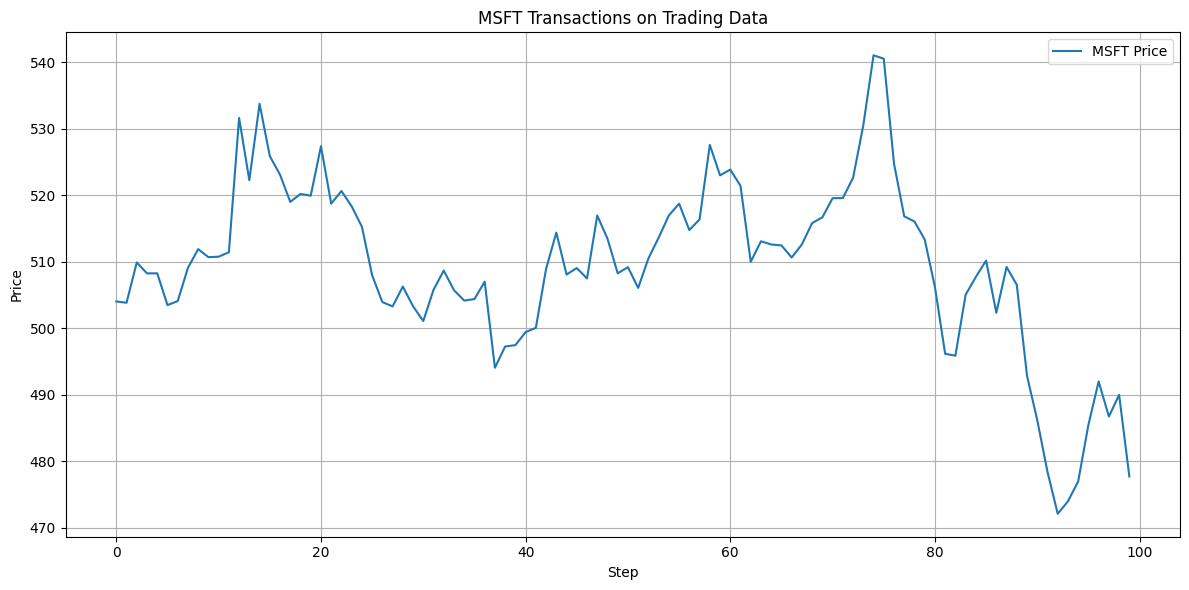

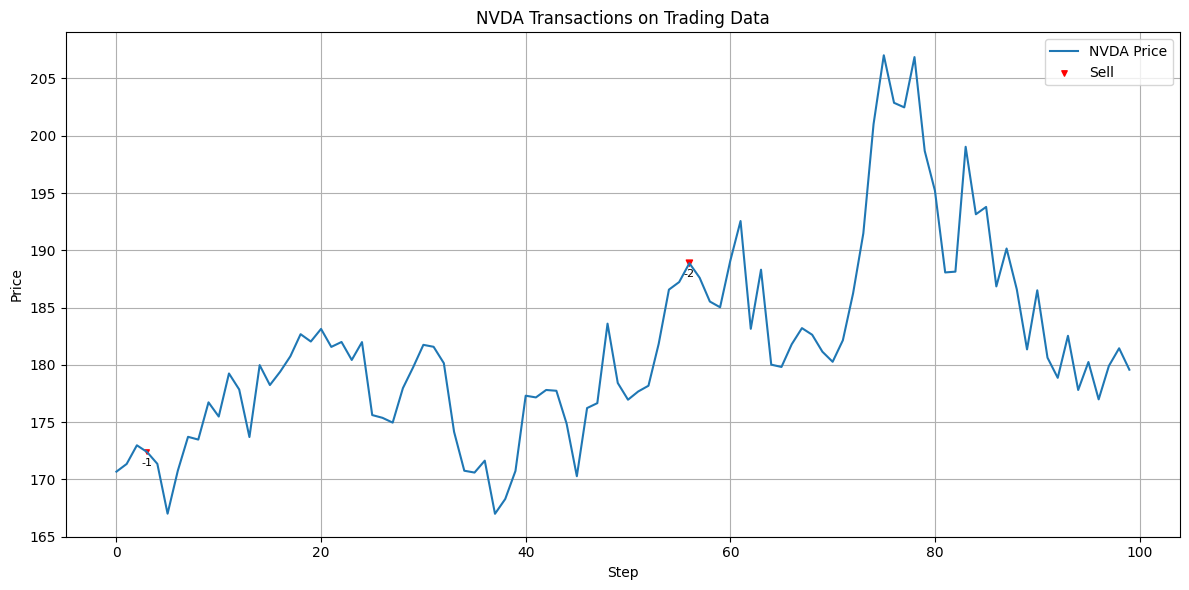

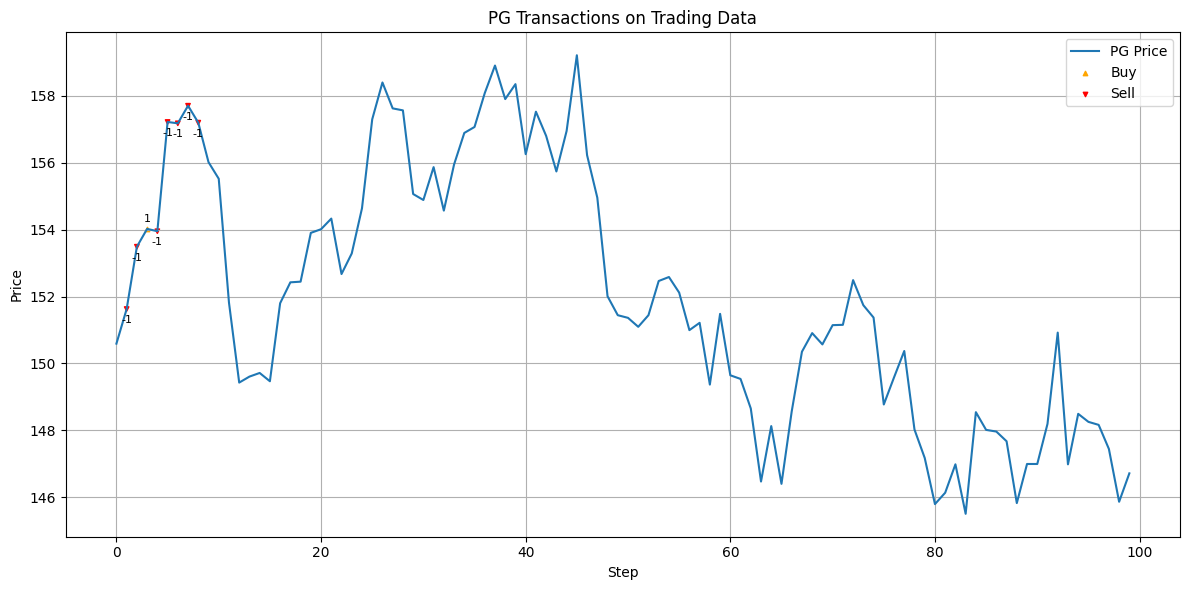

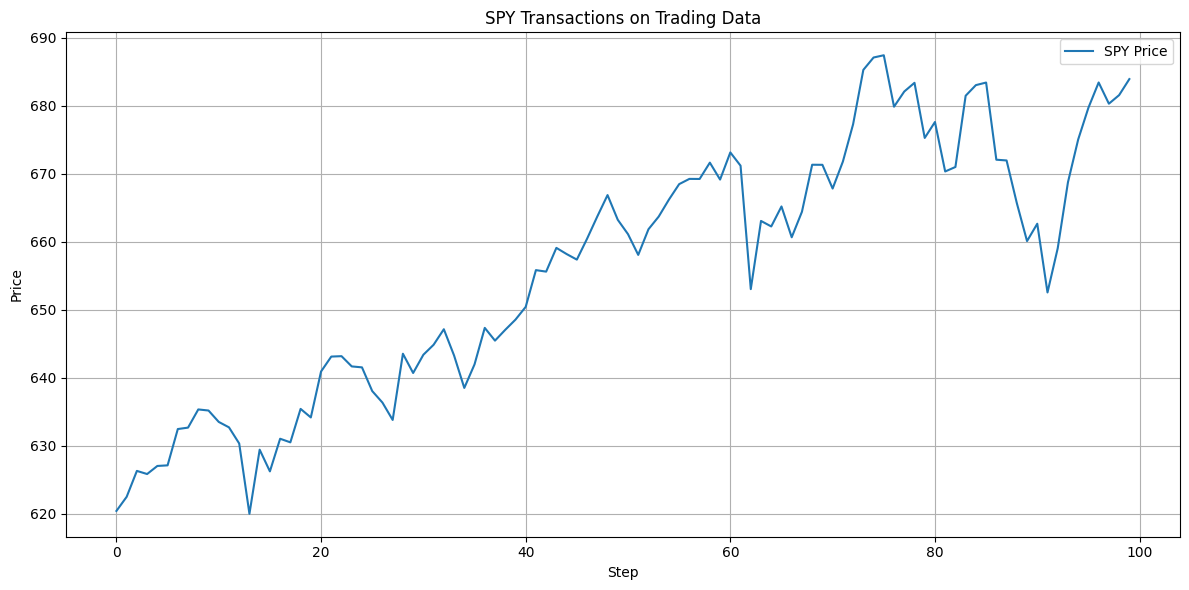

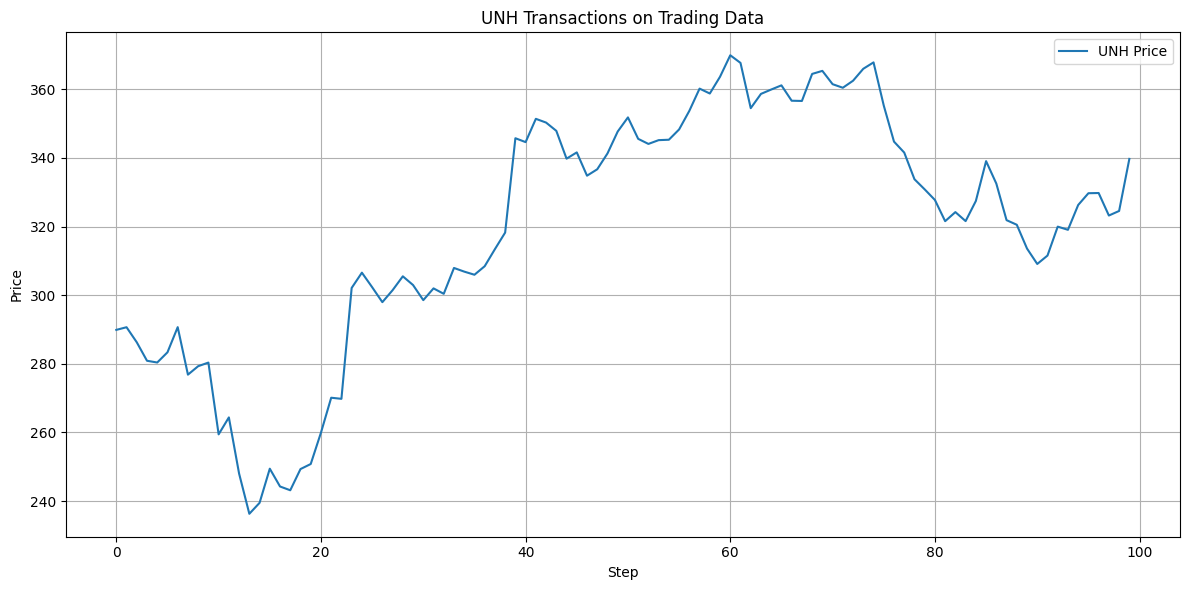

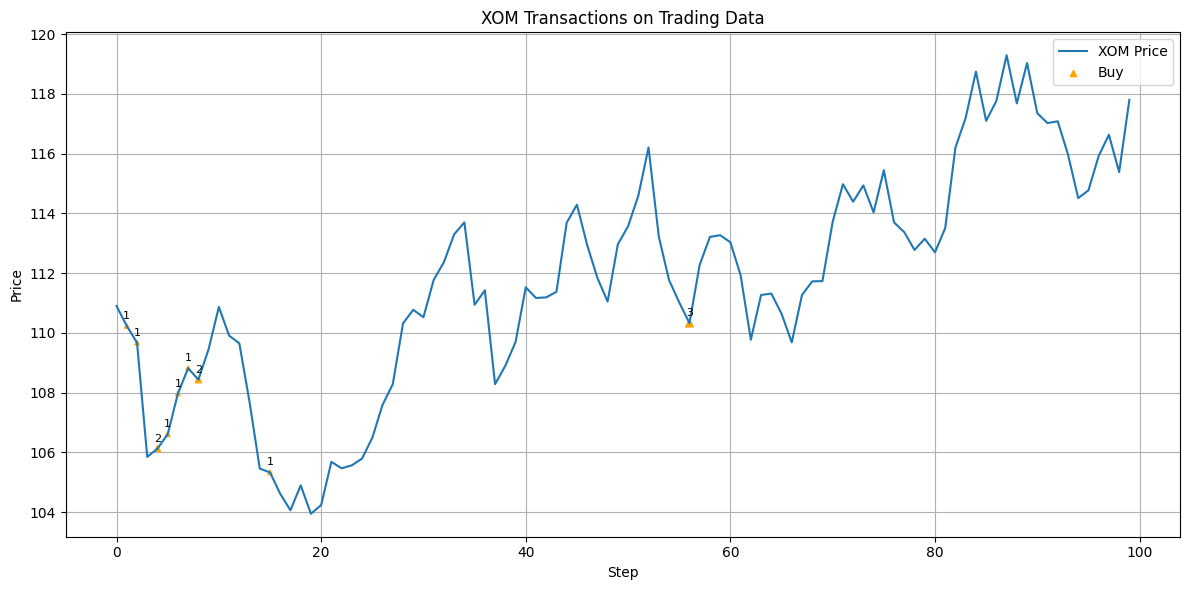

In [44]:
%matplotlib inline
tickers = trade_df['tic'].unique()

for tic in tickers:
    fig, ax = plot_trades_on_price_from_backtest(res, ticker=tic)